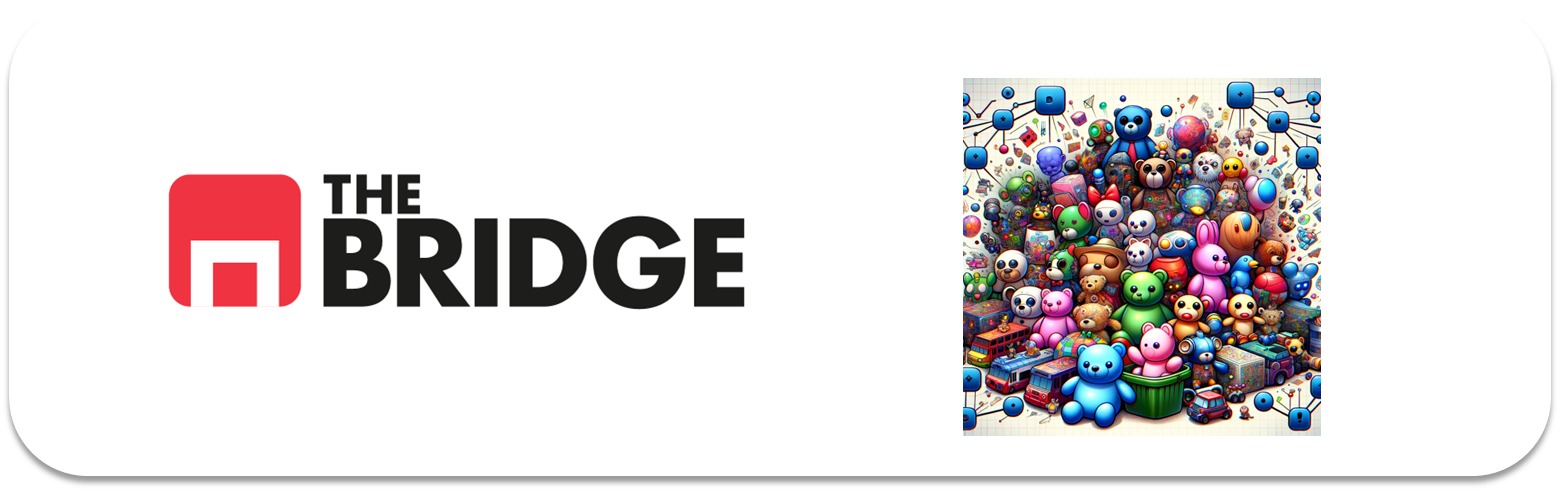

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [3]:
# Cargamos el dataset con el separador correcto
df = pd.read_csv("data/empowering_drinks.csv", sep="|")

# Primeras filas
print(df.head())
print("\n")

# Información general
print(df.info())

   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina
0  1.518613               0.232053  1.034819       1.013009  0.251717
1  0.246290              -0.827996  0.733629       0.965242 -0.293321
2  0.196879               1.109334  1.215533       1.395148  0.269020
3  1.691550               0.487926  1.466525       2.334574  1.186068
4  0.295700               1.840403  0.663351      -0.037874 -0.319276


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB
None


In [4]:
# Estadísticas descriptivas
print(df.describe().round(2))

# Comprobamos si hay nulos
print("\nNulos:")
print(df.isnull().sum())

       Azúcares  Vitamínas del grupo B  Cafeína  Ácido Cítrico  Taurina
count    153.00                 153.00   153.00         153.00   153.00
mean       0.02                   0.04     0.04           0.08    -0.04
std        1.03                   1.00     1.04           1.01     0.93
min       -2.43                  -3.68    -1.70          -1.49    -1.63
25%       -0.82                  -0.50    -1.04          -0.74    -0.80
50%        0.06                  -0.02     0.21          -0.17    -0.15
75%        0.88                   0.71     0.89           0.92     0.49
max        2.26                   3.16     3.06           2.97     2.43

Nulos:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


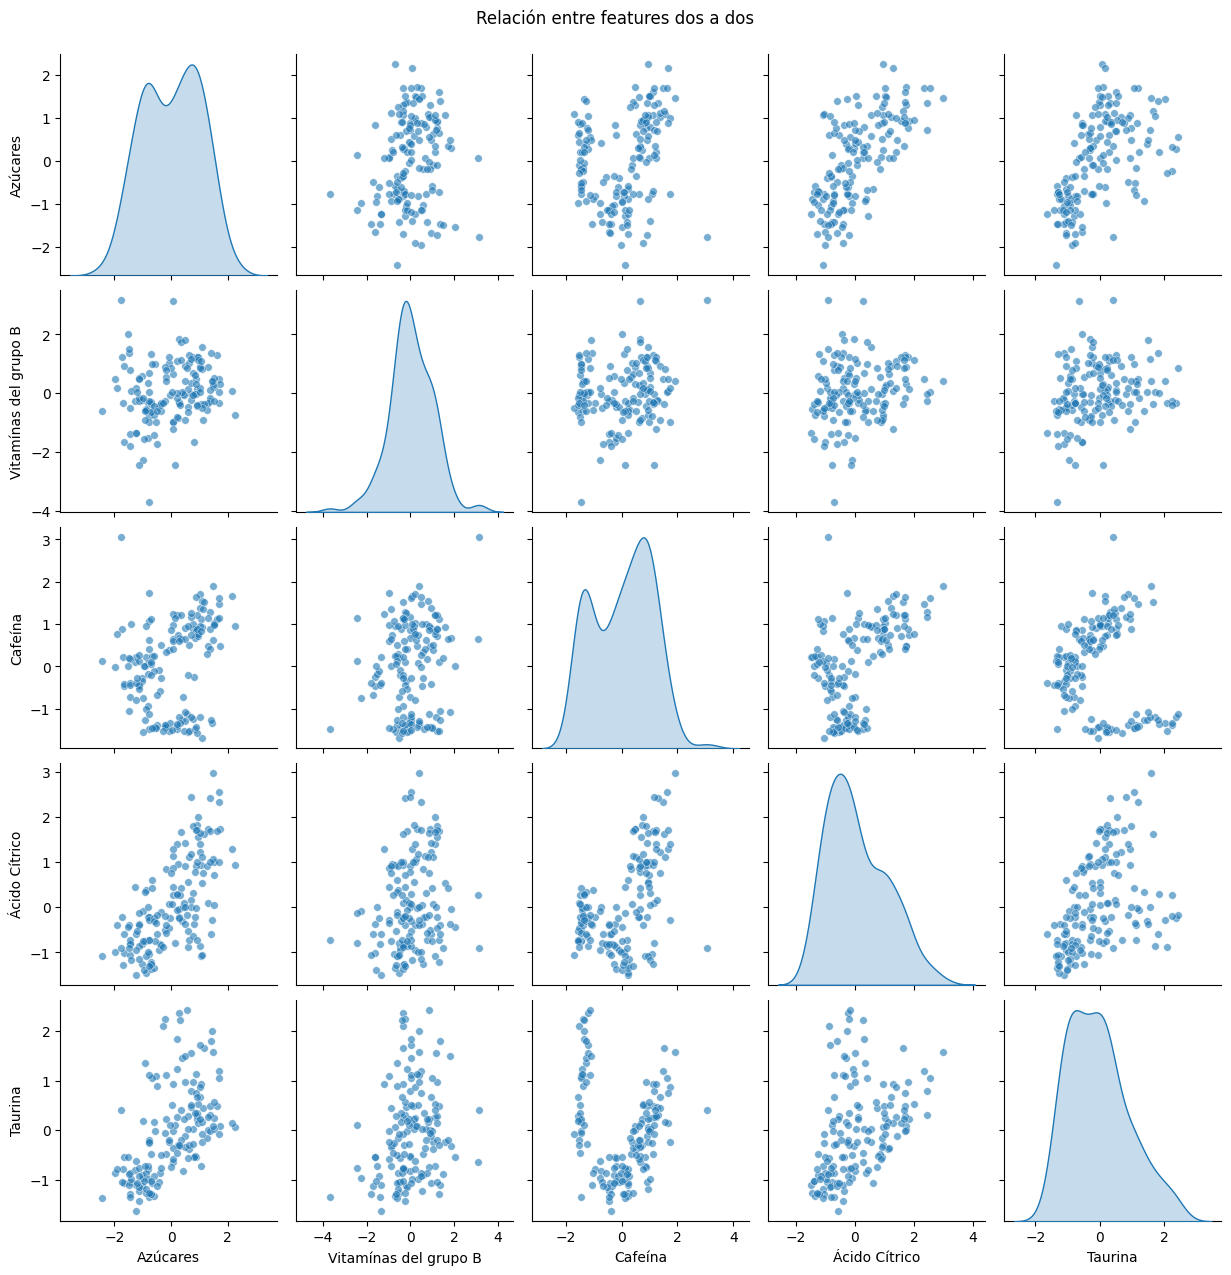

In [5]:
# Visualizamos las features dos a dos con un pairplot
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 30})
plt.suptitle("Relación entre features dos a dos", y=1.02)
plt.show()

## Selección de features

Tras visualizar las combinaciones dos a dos, se eligen **Cafeína** y **Taurina** como 
features para el clustering, por ser el par que muestra una separación visual más clara 
en el pairplot (dos nubes de puntos diferenciadas). El resto de variables (especialmente 
Vitaminas del grupo B) no aportan separación clara y se descartan para simplificar el modelo.

El dataset ya viene escalado de origen (media ≈ 0, desviación ≈ 1), por lo que no es 
necesario aplicar StandardScaler.

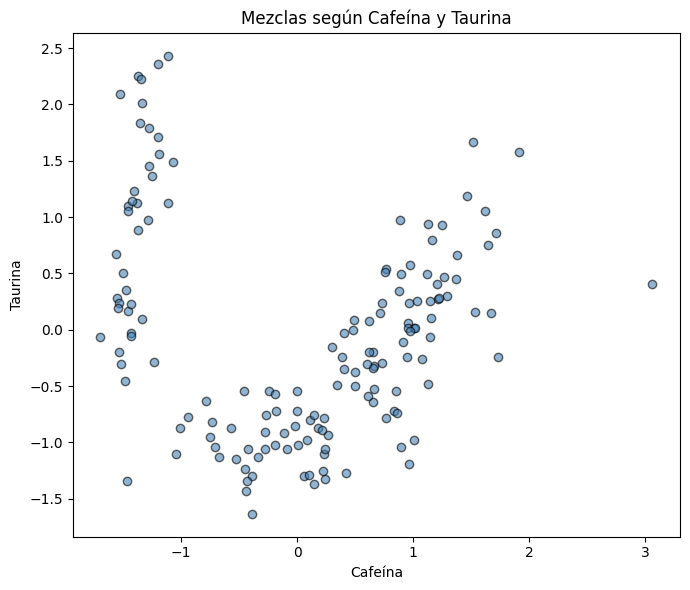

In [6]:
# Seleccionamos las dos features con mejor separación visual
X = df[["Cafeína", "Taurina"]]

# Visualizamos el scatter para confirmar la estructura
plt.figure(figsize=(7, 6))
plt.scatter(X["Cafeína"], X["Taurina"], alpha=0.6, color="steelblue", edgecolor="black")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.title("Mezclas según Cafeína y Taurina")
plt.tight_layout()
plt.show()

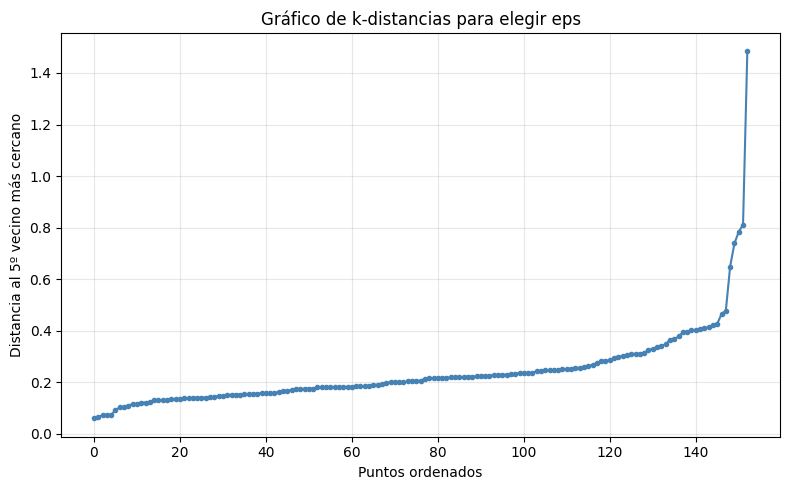

In [7]:
from sklearn.neighbors import NearestNeighbors

# Calculamos la distancia de cada punto a su k-ésimo vecino más cercano
# Usamos k=5 como punto de partida razonable
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X)
distances, indices = neighbors.kneighbors(X)

# Ordenamos las distancias al k-ésimo vecino de menor a mayor
k_distances = np.sort(distances[:, k-1])

# Graficamos para buscar el codo
plt.figure(figsize=(8, 5))
plt.plot(k_distances, marker="o", markersize=3, color="steelblue")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k}º vecino más cercano")
plt.title("Gráfico de k-distancias para elegir eps")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Basándonos en el gráfico de k-distancias, elegimos eps en torno al codo (~0.32)
# min_samples = 5 es un valor razonable de partida (regla habitual: 2 * nº dimensiones = 4, redondeado a 5)
dbscan = DBSCAN(eps=0.32, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Contamos cuántos clusters y cuántos puntos de ruido (-1) hay
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise}")
print(f"\nDistribución de puntos por cluster:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

Número de clusters encontrados: 3
Puntos de ruido: 10

Distribución de puntos por cluster:
-1     10
 0    106
 1     16
 2     21
Name: count, dtype: int64


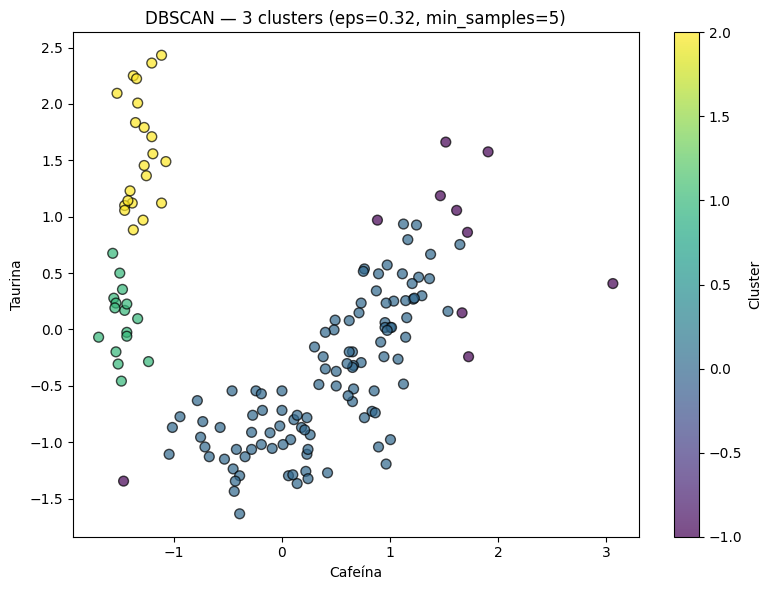

In [9]:
# Visualizamos los clusters encontrados por DBSCAN
plt.figure(figsize=(8, 6))

# Pintamos cada cluster con un color, y el ruido en gris
scatter = plt.scatter(X["Cafeína"], X["Taurina"], c=labels_dbscan, cmap="viridis", 
                       alpha=0.7, edgecolor="black", s=50)
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.title(f"DBSCAN — {n_clusters} clusters (eps=0.32, min_samples=5)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

### Resultado DBSCAN

Con `eps=0.32` y `min_samples=5`, DBSCAN encuentra **3 clusters** y **10 puntos de ruido**:

- Cluster 2 (amarillo): mezclas con cafeína baja y taurina alta — 21 mezclas
- Cluster 1 (verde): mezclas con cafeína baja y taurina media — 16 mezclas  
- Cluster 0 (azul): el grupo más numeroso, cafeína media-alta — 106 mezclas
- Ruido: 10 mezclas atípicas, principalmente con valores de cafeína altos y dispersos

El resultado respeta la geometría no esférica observada en el scatter — DBSCAN agrupa 
por densidad y se adapta a las formas curvas de los datos, algo que K-Means no podría 
hacer al asumir clusters circulares.

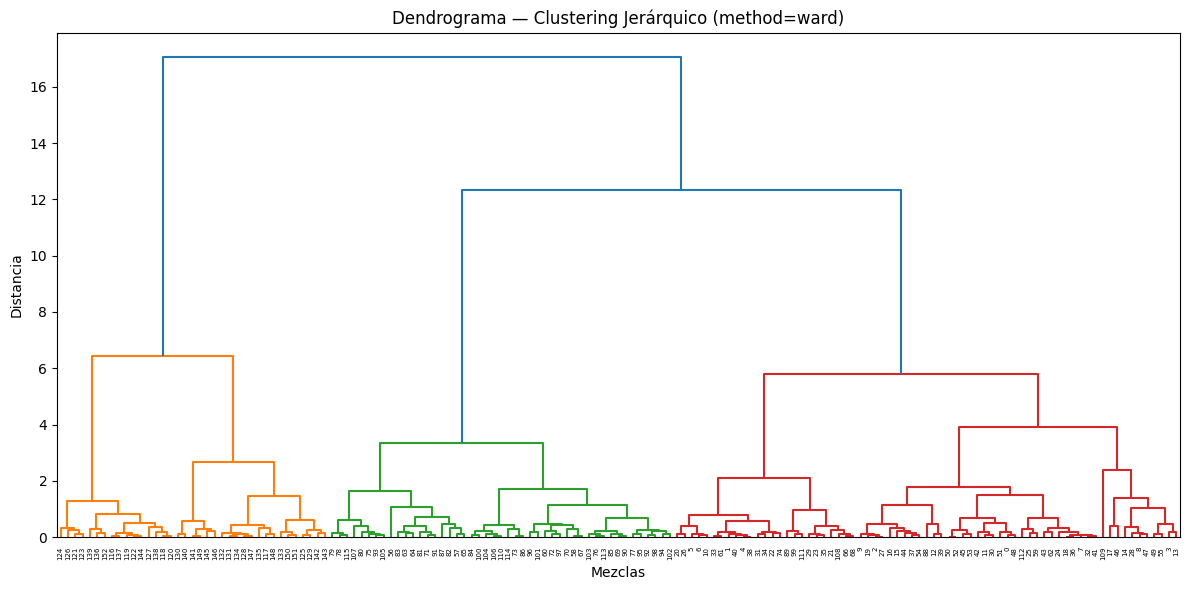

In [10]:
# Calculamos la matriz de enlaces (linkage) usando el método "ward"
# Ward minimiza la varianza dentro de cada cluster al fusionar - suele dar buenos resultados
Z = linkage(X, method="ward")

# Dibujamos el dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.xlabel("Mezclas")
plt.ylabel("Distancia")
plt.title("Dendrograma — Clustering Jerárquico (method=ward)")
plt.tight_layout()
plt.show()

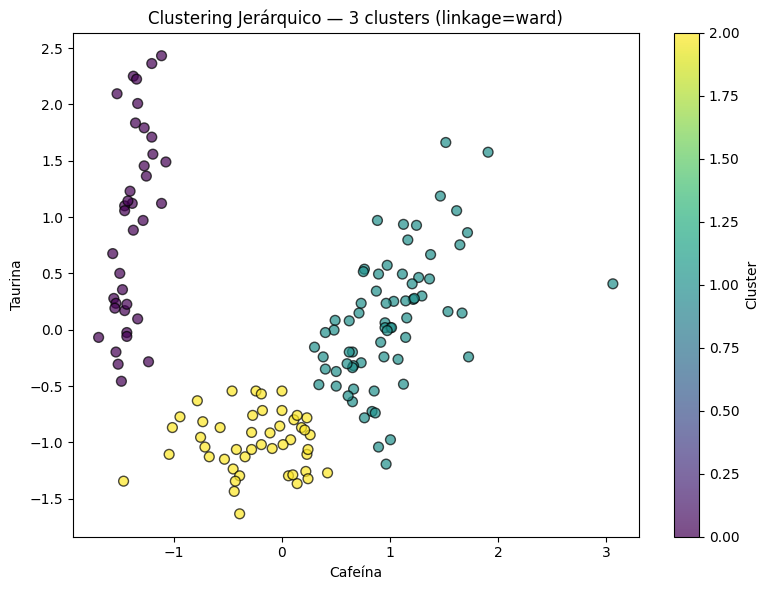

Distribución de puntos por cluster:
0    37
1    69
2    47
Name: count, dtype: int64


In [11]:
# Aplicamos clustering jerárquico con 3 clusters (mismo número que DBSCAN)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_hierarchical = hierarchical.fit_predict(X)

# Visualizamos
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X["Cafeína"], X["Taurina"], c=labels_hierarchical, cmap="viridis", 
                       alpha=0.7, edgecolor="black", s=50)
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.title("Clustering Jerárquico — 3 clusters (linkage=ward)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print("Distribución de puntos por cluster:")
print(pd.Series(labels_hierarchical).value_counts().sort_index())

### Comparación de DBSCAN vs Clustering Jerárquico

| | DBSCAN | Jerárquico |
|---|---|---|
| Nº clusters | 3 | 3 |
| Puntos de ruido | 10 | 0 |
| Cluster cafeína baja/taurina alta | Sí (21 puntos) | Sí (37 puntos, incluye algún outlier) |
| Cluster cafeína baja/taurina negativa | Fusionado con el de la derecha | Separado (69 puntos) |
| Cluster cafeína alta | Fusionado con el anterior | Separado (47 puntos), incluye outliers de la derecha |

**Diferencias clave:**
- DBSCAN aísla los puntos atípicos como ruido; el jerárquico los fuerza dentro de algún cluster.
- DBSCAN respeta mejor la continuidad de densidad entre la nube inferior y el brazo derecho 
  (los considera un solo cluster), mientras que el jerárquico los separa en dos.

**¿Por qué la comparación es meramente especulativa?**

Porque no tenemos ningún target real (etiqueta de "sabor" o "capacidad antifatiga") 
contra el que validar cuál segmentación es la "correcta". Sin un ground truth, no podemos 
decir objetivamente qué algoritmo lo ha hecho mejor — solo podemos describir las diferencias 
estructurales entre ambos resultados y razonar sobre qué tiene más sentido visualmente. 
La validación real solo la podrán dar los químicos al interpretar y probar las mezclas.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [12]:
# Cargamos los nuevos experimentos
df_new = pd.read_csv("data/new_experiments.csv", sep="|")
print(df_new.head())
print("\n")
print(df_new.shape)

   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina
0  1.481555               0.305159  1.366128       2.239039  0.731870
1  0.616869               0.890014  0.583034       0.312420 -0.665332
2 -1.680724               0.341713 -0.340615      -0.213021 -0.976782
3 -0.284874              -1.412851 -0.782361      -1.193845 -0.717240
4 -0.927212               0.634140 -1.565455      -0.085641 -0.522583


(6, 5)


In [13]:
from sklearn.neighbors import NearestNeighbors

# Seleccionamos las mismas dos features que usamos para entrenar (Cafeína, Taurina)
X_new = df_new[["Cafeína", "Taurina"]]

# Buscamos, para cada experimento nuevo, el punto más cercano del dataset original
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X)
distances, nearest_idx = nn.kneighbors(X_new)

# Asignamos la etiqueta de DBSCAN del vecino más cercano
new_labels = labels_dbscan[nearest_idx.flatten()]

# Mostramos el resultado
df_new["cluster_asignado"] = new_labels
df_new["distancia_al_vecino"] = distances.flatten()

print(df_new[["Cafeína", "Taurina", "cluster_asignado", "distancia_al_vecino"]])

    Cafeína   Taurina  cluster_asignado  distancia_al_vecino
0  1.366128  0.731870                 0             0.065658
1  0.583034 -0.665332                 0             0.074917
2 -0.340615 -0.976782                 0             0.088537
3 -0.782361 -0.717240                 0             0.086514
4 -1.565455 -0.522583                 1             0.103252
5 -1.354622  1.956043                 2             0.055657


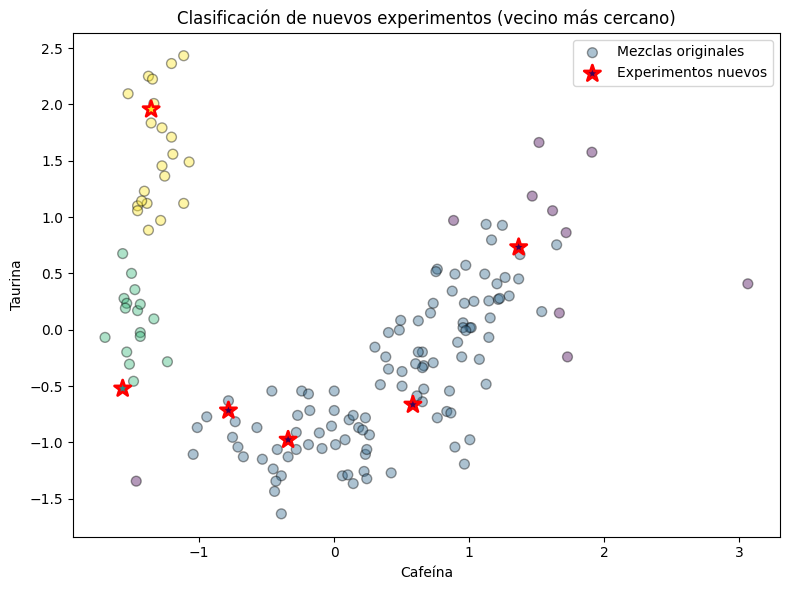

In [14]:
# Visualizamos los experimentos nuevos sobre el mapa de clusters original
plt.figure(figsize=(8, 6))

# Puntos originales con su cluster
plt.scatter(X["Cafeína"], X["Taurina"], c=labels_dbscan, cmap="viridis", 
            alpha=0.4, edgecolor="black", s=50, label="Mezclas originales")

# Puntos nuevos resaltados con borde rojo
plt.scatter(X_new["Cafeína"], X_new["Taurina"], c=new_labels, cmap="viridis", 
            edgecolor="red", linewidth=2, s=150, marker="*", label="Experimentos nuevos")

plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.title("Clasificación de nuevos experimentos (vecino más cercano)")
plt.legend()
plt.tight_layout()
plt.show()


Se clasificaron los 6 experimentos nuevos asignando a cada uno el cluster de DBSCAN 
de su vecino más cercano en el dataset original.

**Resultado:** 4 al cluster 0, 1 al cluster 1, 1 al cluster 2. Todas las distancias 
son pequeñas, así que los experimentos nuevos se parecen a mezclas ya conocidas.

Se usó DBSCAN porque es más fácil de aplicar a datos nuevos que el jerárquico, 
que necesitaría re-entrenar todo el modelo desde cero.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.